In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [2]:
int_clls = ["BXPC3", "CAPAN2", "CFPAC", "HPAFII", "PANC", "SW1990", 'HEK']
standard_names = ["BXPC3", "CAPAN2", "CFPAC1", "HPAFII", "PANC10.05", "SW1990", "HEK293"]

# Fig 1

## Panel b, % inh distribution HTS & confirmation

In [3]:
confirmation = pd.read_excel(
    "../../drug screening data//HTS_and_confirmation.xlsx",
    sheet_name="Training set",
)
hts = pd.read_excel(
    "../../drug screening data//HTS_and_confirmation.xlsx",
    sheet_name="HTS",
)

In [4]:
thresholds = {
    "CAPAN2": np.mean(hts['%Inh CAPAN2'])+np.std(hts['%Inh CAPAN2'])*2.5,
    "SW1990": np.mean(hts['%Inh SW1990'])+np.std(hts['%Inh SW1990'])*2.5,
    "BXPC3": np.mean(hts['%Inh BXPC3'])+np.std(hts['%Inh BXPC3'])*2.5,
    "HPAFII": np.mean(hts['%Inh HPAFII'])+np.std(hts['%Inh HPAFII'])*2.5,
    "CFPAC1": np.mean(hts['%Inh CFPAC1'])+np.std(hts['%Inh CFPAC1'])*2.5,
    "PANC10.05": np.mean(hts['%Inh PANC10.05'])+np.std(hts['%Inh PANC10.05'])*2.5,
    "ASPC1": np.mean(hts['%Inh AsPC-1'])+np.std(hts['%Inh AsPC-1'])*2.5,
    "HEK293": np.percentile(confirmation["%Inh HEK293"], 75),
    "U2OS": np.percentile(confirmation["%Inh U2OS"], 75),
}

In [5]:
confirmation.columns

Index(['SMILES', 'Supplier', 'Supplier Ref', 'CLNUMBER', 'Conc', '%Inh CAPAN2',
       '%Inh SW1990', '%Inh BXPC3', '%Inh HPAFII', '%Inh CFPAC1',
       '%Inh PANC10.05', '%Inh AsPC-1', '%Inh U2OS', '%Inh HEK293',
       'positives CAPAN2', 'positives SW1990', 'positives BXPC3',
       'positives HPAFII', 'positives CFPAC1', 'positives PANC10.05',
       'positives AsPC-1', 'positives U2OS', 'positives HEK293'],
      dtype='object')

In [6]:
hts.columns

Index(['SMILES', 'Supplier', 'Supplier Ref', 'CLNUMBER', 'Conc', '%Inh CAPAN2',
       '%Inh SW1990', '%Inh BXPC3', '%Inh HPAFII', '%Inh CFPAC1',
       '%Inh PANC10.05', '%Inh AsPC-1', 'in_plate_selection',
       'positives CAPAN2', 'positives SW1990', 'positives BXPC3',
       'positives HPAFII', 'positives CFPAC1', 'positives PANC10.05',
       'positives AsPC-1'],
      dtype='object')

Cell: BXPC3, Threshold: 21.95, Hits HTS: 229, Hits confirmation: 164
Cell: CAPAN2, Threshold: 30.94, Hits HTS: 230, Hits confirmation: 170
Cell: CFPAC1, Threshold: 35.05, Hits HTS: 280, Hits confirmation: 166
Cell: HPAFII, Threshold: 20.89, Hits HTS: 121, Hits confirmation: 122
Cell: PANC10.05, Threshold: 27.26, Hits HTS: 272, Hits confirmation: 197
Cell: SW1990, Threshold: 36.89, Hits HTS: 290, Hits confirmation: 134
Cell: HEK293, Threshold: 48.15, Hits confirmation: 188
Cell: U2OS, Threshold: 64.28, Hits confirmation: 188


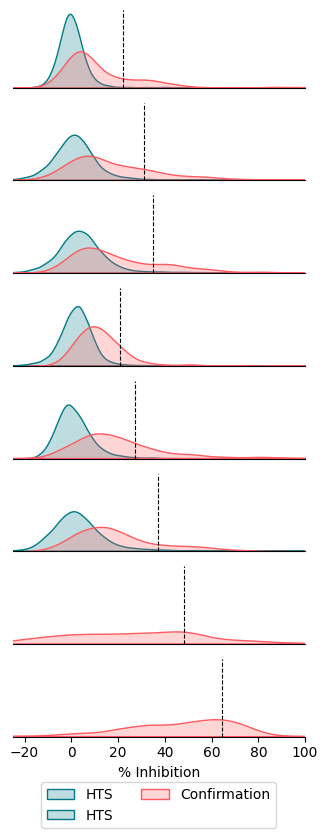

In [34]:
COLORS = ["#007A87", "#FF5A5F"]

fig, axs = plt.subplots(nrows=8, ncols=1, figsize=(3.5, 8))
axs = axs.flatten()  # needed to access each individual axis
# Create empty lists to store legend handles and labels
legend_handles = []
legend_labels = []

# iterate over axes
a = 0
for i, cll in enumerate(standard_names + ["U2OS"]):

    # subset the data for each word
    try:
        subset1 = hts['%Inh '+cll]
        # plot the distribution of prices
        sns.kdeplot(
            subset1,
            fill=True,
            # bw_adjust = 1,
            ax=axs[i],
            label="HTS",
            color=COLORS[0],
        )
        if i == 0:
            # Store legend information for the first plot only
            h, l = axs[i].get_legend_handles_labels()
            legend_handles.extend(h)
            legend_labels.extend(l)

    except:
        a = 1

    subset2 = confirmation['%Inh '+cll]
    sns.kdeplot(
        subset2,
        fill=True,
        # bw_adjust = 1,
        ax=axs[i],
        label="Confirmation",
        color=COLORS[1],
    )

    # set title and labels
    axs[i].set_xlim(-25, 100)
    axs[i].set_ylim(0, 0.085)
    axs[i].set_ylabel("")

    # x axis scale for last ax
    axs[i].spines[["right", "top", "left"]].set_visible(False)
    axs[i].set_yticks([])

    # if i == 0:
    #     axs[i].legend()
    if i == 0:
        # Store legend information for the first plot only
        h, l = axs[i].get_legend_handles_labels()
        legend_handles.extend(h)
        legend_labels.extend(l)
    if i != 7:
        axs[i].set_xticks([])
        axs[i].set_xlabel("")
    else:
        axs[i].set_xlabel("% Inhibition")

    axs[i].axvline(thresholds[cll], color="black", linestyle="--", linewidth=0.8)

    if a == 1: # if cell line is U2OS or HEK293 (not in HTS)
        print(f"Cell: {cll}, Threshold: {thresholds[cll]:.2f}, Hits confirmation: {sum(subset2 > thresholds[cll])}")
    else:
        print(f"Cell: {cll}, Threshold: {thresholds[cll]:.2f}, Hits HTS: {sum(subset1 > thresholds[cll])}, Hits confirmation: {sum(subset2 > thresholds[cll])}")

fig.legend(
    legend_handles,
    legend_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=2,
)
plt.tight_layout()

plt.show()

## Panel c,  tSNE representation of the chemical space of the compounds in the HTS and public libraries.

In [37]:
from sklearn.manifold import TSNE
import pickle

In [39]:
signatures_path = "../extra_data/" # GLOBAL signatures are obtained in the same way than in cytotoxics_design/cytotoxicity_prediction_models/run_predictions.py

### GLOBAL Signature

In [40]:
with open(signatures_path + "signatures_databases.p", "rb") as f:
    sig_dict = pickle.load(f)

In [41]:
with open(signatures_path + "signatures_HTS.p", "rb") as f:
    sig_irb = pickle.load(f)

In [42]:
sig_irb.shape

(11053, 3200)

In [43]:
X = sig_dict["nci"]
for s in ["drugcell", "ctrp", "gdsc"]:
    X = np.concatenate([X, sig_dict[s]])
print(X.shape)
X = np.concatenate([X, sig_irb])

(23244, 3200)


In [44]:
X.shape

(34297, 3200)

In [45]:
np.unique(np.where(np.isnan(X))[0])

array([], dtype=int64)

In [46]:
X = np.delete(X, [np.unique(np.where(np.isnan(X))[0])], 0)
X.shape

(34297, 3200)

In [47]:
X_tsne = TSNE(n_components=2, random_state=354).fit_transform(X)

In [48]:
label = (
    ["NCI60"] * len(sig_dict["nci"])
    + ["DrugCell"] * len(sig_dict["drugcell"])
    + ["CTRP"] * len(sig_dict["ctrp"])
    + ["GDSC"] * len(sig_dict["gdsc"])
    + ["IRB"] * len(sig_irb)
)

color = {
    "NCI60": "lightgrey",
    "IRB": "tab:blue",
    "DrugCell": "tab:orange",
    "CTRP": "tab:green",
    "GDSC": "tab:red",
}

In [49]:
import matplotlib.colors as colors


def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        "trunc({n},{a:.2f},{b:.2f})".format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)),
    )
    return new_cmap


cmap = plt.get_cmap("Greys")
bckg_cmap = truncate_colormap(cmap, 0.2, 0.6)

lib_to_cmap = {
    "IRB": "Blues",
    "GDSC": "Reds",
    "CTRP": "Greens",
    "DrugCell": "Purples",
    "NCI60": bckg_cmap,
}
irb_cmap = truncate_colormap(plt.get_cmap(lib_to_cmap["IRB"]), 0.2, 1)
lib_to_cmap = {
    "IRB": irb_cmap,
    "GDSC": "Reds",
    "CTRP": "Greens",
    "DrugCell": "Purples",
    "NCI60": bckg_cmap,
}

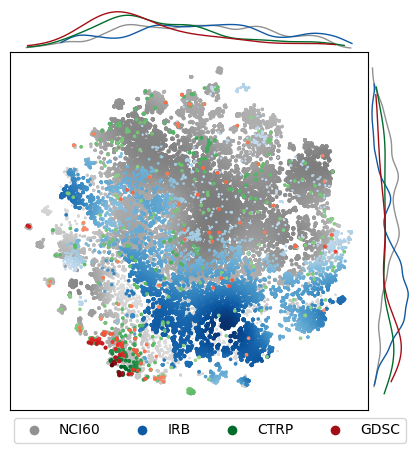

In [50]:
# Plot data
from scipy.interpolate import interpn
from scipy import stats

fig = plt.figure(figsize=(5, 5))

legend_elements = []
gs = fig.add_gridspec(
    2,
    2,
    width_ratios=(9, 1),
    height_ratios=(1, 9),
    left=0.1,
    right=0.9,
    bottom=0.1,
    top=0.9,
    wspace=0.01,
    hspace=0.01,
)

# Main scatter plot
ax = fig.add_subplot(gs[1, 0])

# Top density plot
ax_top = fig.add_subplot(gs[0, 0], sharex=ax)

# Right density plot
ax_right = fig.add_subplot(gs[1, 1], sharey=ax)

for s in ["NCI60", "IRB"]:
    max_size = 10
    min_size = 2
    ax.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)

    # Load data
    X_tsne_aux = X_tsne[np.array(label) == s]

    x = X_tsne_aux[:, 0]
    y = X_tsne_aux[:, 1]
    # Density
    data_e, x_e, y_e = np.histogram2d(x, y, bins=10, density=True)
    z = interpn(
        (0.65 * (x_e[1:] + x_e[:-1]), 0.65 * (y_e[1:] + y_e[:-1])),
        data_e,
        np.vstack([x, y]).T,
        method="splinef2d",
        bounds_error=False,
    )
    z[np.where(np.isnan(z))] = 0.0
    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]
    # Dot size
    min_z = min(z)
    max_z = max(z)
    size = [min_size + (i - min_z) / (max_z - min_z) * (max_size - min_size) for i in z]
    # Plot
    ax.scatter(x, y, c=z, s=size, alpha=1, lw=0, cmap=lib_to_cmap[s], label=s)

    cmap = lib_to_cmap[s]
    # Density plots
    density_x = stats.gaussian_kde(x)
    density_y = stats.gaussian_kde(y)
    x_range = np.linspace(min(x), max(x), 200)
    y_range = np.linspace(min(y), max(y), 200)

    ax_top.plot(x_range, density_x(x_range), color=cmap(0.8), lw=1)
    ax_right.plot(density_y(y_range), y_range, color=cmap(0.8), lw=1)

    # Add to legend elements
    legend_elements.append(
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label=s,
            markerfacecolor=cmap(0.8),
            markersize=8,
        )
    )


for s in ["CTRP", "GDSC"]:
    max_size = 10
    min_size = 7
    # Load data
    X_tsne_aux = X_tsne[np.array(label) == s]

    x = X_tsne_aux[:, 0]
    y = X_tsne_aux[:, 1]
    # Density
    data_e, x_e, y_e = np.histogram2d(x, y, bins=10, density=True)
    z = interpn(
        (0.65 * (x_e[1:] + x_e[:-1]), 0.65 * (y_e[1:] + y_e[:-1])),
        data_e,
        np.vstack([x, y]).T,
        method="splinef2d",
        bounds_error=False,
    )
    z[np.where(np.isnan(z))] = 0.0
    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]
    # Dot size
    min_z = min(z)
    max_z = max(z)
    size = [min_size + (i - min_z) / (max_z - min_z) * (max_size - min_size) for i in z]
    # Plot
    cmap = truncate_colormap(plt.get_cmap(lib_to_cmap[s]), 0.4, 1)
    ax.scatter(x, y, c=z, s=size, alpha=1, lw=0, cmap=cmap, label=s)

    # Density plots
    density_x = stats.gaussian_kde(x)
    density_y = stats.gaussian_kde(y)
    x_range = np.linspace(min(x), max(x), 200)
    y_range = np.linspace(min(y), max(y), 200)

    ax_top.plot(x_range, density_x(x_range), color=cmap(0.8), lw=1)
    ax_right.plot(density_y(y_range), y_range, color=cmap(0.8), lw=1)

    # Add to legend elements
    legend_elements.append(
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label=s,
            markerfacecolor=cmap(0.8),
            markersize=8,
        )
    )
# Adjust density plots
ax_top.axis("off")
ax_right.axis("off")

# Remove spines from all subplots
for a in [ax_top, ax_right]:
    for spine in a.spines.values():
        spine.set_visible(False)

fig.legend(
    handles=legend_elements, loc="lower center", ncol=4, bbox_to_anchor=(0.5, 0.02)
)

plt.show()

### Morgan Fingerprints

In [51]:
from rdkit import Chem
from rdkit.Chem import AllChem


def compute_morgan_fingerprint(smiles, radius=2, nBits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
    return None

In [52]:
ctrp = pd.read_csv(
    "../extra_data/CTRPv2_data.csv"
)
print(ctrp.shape)
gdsc = pd.read_csv(
    "../extra_data/GDSC_data.csv"
)
gdsc.shape

(887, 486)


(4075, 9)

In [53]:
ctrp.head(1)  # 0 - complete cell killing, 1 - no effect

,cell line name,cell line ID,B([C@H](CC(C)C)NC(=O)[C@H](Cc1ccccc1)NC(=O)c2cnccn2)(O)O,Brc1ccc(OCc2ccccc2Br)c(/C=C3/SC(=S)NC3=O)c1,Brc1ccc(cc1)\C=C1/SC(NS(=O)(=O)c2cccc3ccccc23)=NC1=O,C1=C(C(=O)NC(=O)N1)F,C1=C(SC(=C1)C2=CC=C(O2)C3=CC=C(S3)CO)CO,C1=C(SC=C1Br)COC2=NC(=NC3=C2NC=N3)N,C1=C/C(=C/NNC(=O)COC2=C(C=C(C=C2Cl)Cl)Cl)/N=C1,C1=CC(=C(C=C1I)F)NC2=C(C(=C(C=C2C(=O)NOCC(CO)O)Br)F)F,...,OC[C@@H]1O[C@@H](CC(=O)NCc2ccncn2)CC[C@H]1NC(=O)c1ccc(F)cc1,ONC(=O)c1cccc(c1)C(=O)Nc1ccccc1,ONC(=O)c1ccncc1,ONC1=c2ccccc2=NC1=C3C(=O)Nc4cc(Br)ccc34,O[As](O)(=O)c1ccc(Cc2ccc(cc2)[As](O)(O)=O)cc1,Oc1c(CC=C)cccc1C=NNC(=O)CN2CCN(Cc3ccccc3)CC2,Oc1cc(O)c2c(=O)c(O)c(oc2c1)c3cc(O)c(O)c(O)c3,Oc1ccc(C[C@@H]2N3[C@H](CN(Cc4cccc5ccccc45)C2=O)N(CCC3=O)C(=O)NCc2ccccc2)cc1,Oc1ccc(Cl)cc1C(=O)Nc2ccc(cc2Cl)[N+](=O)[O-],Oc1cccc2cc(C(=O)Nc3cccc(c3)-c3cn4ccccc4n3)c(=O)oc12
0,2004,CVCL_U759,0.237798,0.064738,0.001045,0.197994,0.091708,0.069529,0.001246,0.27233,...,NaN,0.098514,0.040281,0.187653,0.053147,0.149822,0.04853,0.139868,0.154188,0.001365


In [54]:
ctrp["cell line ID"].unique()

array(['CVCL_U759', 'CVCL_1045', 'CVCL_1046', 'CVCL_7935', 'CVCL_7937',
       'CVCL_1798', 'CVCL_0126', 'CVCL_1048', 'CVCL_1049', nan,
       'CVCL_1050', 'CVCL_1051', 'CVCL_1053', 'CVCL_1054', 'CVCL_1052',
       'CVCL_1057', 'CVCL_0131', 'CVCL_1058', 'CVCL_1059', 'CVCL_1060',
       'CVCL_0134', 'CVCL_0132', 'CVCL_1062', 'CVCL_1056', 'CVCL_1064',
       'CVCL_0023', 'CVCL_0080', 'CVCL_5113', 'CVCL_1067', 'CVCL_0139',
       'CVCL_1805', 'CVCL_1070', 'CVCL_1071', 'CVCL_1806', 'CVCL_0028',
       'CVCL_6C43', 'CVCL_0152', 'CVCL_1074', 'CVCL_1958', 'CVCL_0107',
       'CVCL_0153', 'CVCL_4613', 'CVCL_1093', 'CVCL_1082', 'CVCL_1083',
       'CVCL_1084', 'CVCL_1085', 'CVCL_1086', 'CVCL_2308', 'CVCL_2309',
       'CVCL_2310', 'CVCL_2312', 'CVCL_2313', 'CVCL_2314', 'CVCL_1087',
       'CVCL_1088', 'CVCL_WW37', 'CVCL_M155', 'CVCL_WW38', 'CVCL_WW39',
       'CVCL_IP10', 'CVCL_IP11', 'CVCL_M156', 'CVCL_IP12', 'CVCL_WW43',
       'CVCL_WW46', 'CVCL_0178', 'CVCL_WW49', 'CVCL_WW50', 'CVCL_WW51',


In [55]:
gdsc.head(2)  # negative - sensitive, positive - resistant

,ID,Drug Name,Targets,Z score,Count,Cell line name,SMILES,cell ID,CPD
0,1372,Trametinib,"MEK1, MEK2",-0.409367,180,AsPC1,CC1=C2C(=C(N(C1=O)C)NC3=C(C=C(C=C3)I)F)C(=O)N(...,CVCL_0152,CC(=O)Nc1cccc(-n2c(=O)n(C3CC3)c(=O)c3c(Nc4ccc(...
1,1060,PD0325901,"MEK1, MEK2",-0.367114,180,AsPC1,C1=CC(=C(C=C1I)F)NC2=C(C=CC(=C2F)F)C(=O)NOC[C@...,CVCL_0152,O=C(NOC[C@H](O)CO)c1ccc(F)c(F)c1Nc1ccc(I)cc1F


In [56]:
gdsc["Cell line name"].unique()

array(['AsPC1', 'BxPC3', 'CAPAN1', 'CAPAN2', 'CFPAC1', 'DANG', 'HPAC',
       'HPAFII', 'Hs766T', 'HuPT3', 'HuPT4', 'KP1N', 'KP2', 'KP3',
       'MIAPaCa2', 'PANC0203', 'PANC0327', 'PANC0403', 'PANC0813',
       'PANC1005', 'PATU8902', 'PATU8988T', 'PL18', 'PL4', 'PSN1',
       'SU8686', 'SUIT2', 'SW1990', 'YAPC', 'KP4'], dtype=object)

In [57]:
# gdsc= gdsc[gdsc['Cell line name'].isin(['BxPC3','CAPAN2','CFPAC1','HPAFII','PANC1005','SW1990'])]
gdsc.shape

(4075, 9)

In [58]:
len(np.unique(gdsc["cell ID"]))

30

In [ ]:
from tqdm import tqdm

smiles_gdsc = np.unique(gdsc["SMILES"][gdsc["SMILES"].notnull()])
len(smiles_gdsc)

140

In [ ]:
smiles_ctrp = np.unique(ctrp.columns[2:])

len(smiles_ctrp)

484

In [61]:
nci60 = pd.read_excel(
    "/aloy/home/grojas/tesis/cell_line_specific_NCEs/data/NCI60/DTP_NCI60_ZSCORE/output/DTP_NCI60_ZSCORE.xlsx",
    skiprows=8,
)
nci60.head(1)

,NSC # b,Drug name,FDA status,Mechanism of action c,PubChem SID,SMILES d,BR:MCF7,BR:MDA-MB-231,BR:HS 578T,BR:BT-549,...,RE:786-0,RE:A498,RE:ACHN,RE:CAKI-1,RE:RXF 393,RE:SN12C,RE:TK-10,RE:UO-31,Total experiments e,Total after quality control f
0,1,tolylquinone,-,-,-,CC1=CC(=O)C=CC1=O,-0.27,-0.3,-0.82,-0.23,...,-0.52,-1.65,1.66,-0.27,0,-0.39,-0.38,1.06,3,2


In [62]:
smiles_nci = np.unique(nci60["SMILES d"])
smiles_nci = smiles_nci[1:]
len(smiles_nci)

23441

In [63]:
smiles_nci

array(['B.C(CN1CC1)O[Si](c2ccccc2)(c3ccccc3)c4ccccc4',
       'B.CS(=O)(=O)O[C@H]1CN2C[C@@H](O)[C@@H](O)[C@H]2[C@H]1CO',
       'BC(=O)NC(CC(C)C)C(=O)NCC(=O)NC1C(O)C(=O)c2sccc12', ...,
       'o1cccc1\\C=C\\c2cccc(\\C=C\\c3occc3)n2',
       'o1cccc1\\C=N\\c2ccc(cc2)c3nc4ccccc4s3',
       'o1cccc1\\C=N\\c2ccc(cc2)c3oc4ccccc4n3'],
      shape=(23441,), dtype=object)

In [64]:
sum(np.isin(smiles_ctrp, smiles_gdsc))

np.int64(25)

In [65]:
sum(np.isin(smiles_ctrp, smiles_nci))

np.int64(13)

In [66]:
sum(np.isin(smiles_gdsc, smiles_nci))

np.int64(1)

In [67]:
gdsc.head()

,ID,Drug Name,Targets,Z score,Count,Cell line name,SMILES,cell ID,CPD
0,1372,Trametinib,"MEK1, MEK2",-0.409367,180,AsPC1,CC1=C2C(=C(N(C1=O)C)NC3=C(C=C(C=C3)I)F)C(=O)N(...,CVCL_0152,CC(=O)Nc1cccc(-n2c(=O)n(C3CC3)c(=O)c3c(Nc4ccc(...
1,1060,PD0325901,"MEK1, MEK2",-0.367114,180,AsPC1,C1=CC(=C(C=C1I)F)NC2=C(C=CC(=C2F)F)C(=O)NOC[C@...,CVCL_0152,O=C(NOC[C@H](O)CO)c1ccc(F)c(F)c1Nc1ccc(I)cc1F
2,1736,Selumetinib,"MEK1, MEK2",-0.121602,180,AsPC1,CN1C=NC2=C1C=C(C(=C2F)NC3=C(C=C(C=C3)Br)Cl)C(=...,CVCL_0152,Cn1cnc2c(F)c(Nc3ccc(Br)cc3Cl)c(C(=O)NOCCO)cc21
3,2046,MK-8776,"CHEK1, CHEK2, CDK2",0.081265,180,AsPC1,CN1C=C(C=N1)C2=C3N=C(C(=C(N3N=C2)N)Br)C4CCCNC4,CVCL_0152,Cn1cc(-c2cnn3c(N)c(Br)c(C4CCCNC4)nc23)cn1
4,1053,MK-2206,"AKT1, AKT2",0.214599,180,AsPC1,C1CC(C1)(C2=CC=C(C=C2)C3=C(C=C4C(=N3)C=CN5C4=N...,CVCL_0152,NC1(c2ccc(-c3nc4ccn5c(=O)[nH]nc5c4cc3-c3ccccc3...


In [68]:
smiles_full = (
    list(smiles_nci)
    + list(smiles_ctrp)
    + list(smiles_gdsc)
    + list(hts["SMILES"].values)
)

In [69]:
len(smiles_full)

35118

In [ ]:
# Compute Morgan fingerprints 
mfps = [compute_morgan_fingerprint(smi) for smi in smiles_full]
X_mfp = np.array([np.array(fp) for fp in mfps if fp is not None])

[19:30:49] DEPRECATION WARNING: please use MorganGenerator
[19:30:49] DEPRECATION WARNING: please use MorganGenerator
[19:30:49] DEPRECATION WARNING: please use MorganGenerator
[19:30:49] DEPRECATION WARNING: please use MorganGenerator
[19:30:49] DEPRECATION WARNING: please use MorganGenerator
[19:30:49] DEPRECATION WARNING: please use MorganGenerator
[19:30:49] DEPRECATION WARNING: please use MorganGenerator
[19:30:49] DEPRECATION WARNING: please use MorganGenerator
[19:30:49] DEPRECATION WARNING: please use MorganGenerator
[19:30:49] DEPRECATION WARNING: please use MorganGenerator
[19:30:49] DEPRECATION WARNING: please use MorganGenerator
[19:30:49] DEPRECATION WARNING: please use MorganGenerator
[19:30:49] DEPRECATION WARNING: please use MorganGenerator
[19:30:49] DEPRECATION WARNING: please use MorganGenerator
[19:30:49] DEPRECATION WARNING: please use MorganGenerator
[19:30:49] DEPRECATION WARNING: please use MorganGenerator
[19:30:49] DEPRECATION WARNING: please use MorganGenerat

In [71]:
labels = np.array(
    ["NCI60"] * len(smiles_nci)
    + ["CTRPv2"] * len(smiles_ctrp)
    + ["GDSC2"] * len(smiles_gdsc)
    + ["IRB"] * len(hts)
)
labels = labels[~pd.isnull(mfps)]
len(labels)

34787

In [72]:
X_mfp.shape

(34787, 2048)

In [73]:
X_tsne_mfp = TSNE(n_components=2, random_state=354).fit_transform(X_mfp)

In [74]:
lib_to_cmap["CTRPv2"] = "Greens"
lib_to_cmap["GDSC2"] = "Reds"

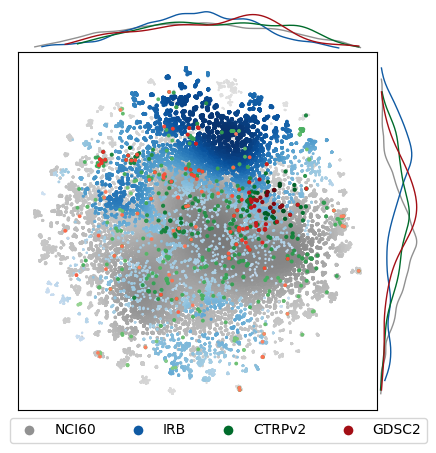

In [ ]:
# Plot data
from scipy.interpolate import interpn
from scipy import stats

fig = plt.figure(figsize=(5, 5))

legend_elements = []
gs = fig.add_gridspec(
    2,
    2,
    width_ratios=(9, 1),
    height_ratios=(1, 9),
    left=0.1,
    right=0.9,
    bottom=0.1,
    top=0.9,
    wspace=0.01,
    hspace=0.01,
)

# Main scatter plot
ax = fig.add_subplot(gs[1, 0])

# Top density plot
ax_top = fig.add_subplot(gs[0, 0], sharex=ax)

# Right density plot
ax_right = fig.add_subplot(gs[1, 1], sharey=ax)

for s in ["NCI60", "IRB"]:
    max_size = 10
    min_size = 2
    ax.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)

    # Load data
    X_tsne_aux = X_tsne_mfp[np.array(labels) == s]

    x = X_tsne_aux[:, 0]
    y = X_tsne_aux[:, 1]
    # Density
    data_e, x_e, y_e = np.histogram2d(x, y, bins=10, density=True)
    z = interpn(
        (0.65 * (x_e[1:] + x_e[:-1]), 0.65 * (y_e[1:] + y_e[:-1])),
        data_e,
        np.vstack([x, y]).T,
        method="splinef2d",
        bounds_error=False,
    )
    z[np.where(np.isnan(z))] = 0.0
    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]
    # Dot size
    min_z = min(z)
    max_z = max(z)
    size = [min_size + (i - min_z) / (max_z - min_z) * (max_size - min_size) for i in z]
    # Plot
    ax.scatter(x, y, c=z, s=size, alpha=1, lw=0, cmap=lib_to_cmap[s], label=s)

    cmap = lib_to_cmap[s]
    # Density plots
    density_x = stats.gaussian_kde(x)
    density_y = stats.gaussian_kde(y)
    x_range = np.linspace(min(x), max(x), 200)
    y_range = np.linspace(min(y), max(y), 200)

    ax_top.plot(x_range, density_x(x_range), color=cmap(0.8), lw=1)
    ax_right.plot(density_y(y_range), y_range, color=cmap(0.8), lw=1)

    # Add to legend elements
    legend_elements.append(
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label=s,
            markerfacecolor=cmap(0.8),
            markersize=8,
        )
    )


for s in ["CTRPv2", "GDSC2"]:
    max_size = 10
    min_size = 7
    # Load data
    X_tsne_aux = X_tsne_mfp[np.array(labels) == s]

    x = X_tsne_aux[:, 0]
    y = X_tsne_aux[:, 1]
    # Density
    data_e, x_e, y_e = np.histogram2d(x, y, bins=10, density=True)
    z = interpn(
        (0.65 * (x_e[1:] + x_e[:-1]), 0.65 * (y_e[1:] + y_e[:-1])),
        data_e,
        np.vstack([x, y]).T,
        method="splinef2d",
        bounds_error=False,
    )
    z[np.where(np.isnan(z))] = 0.0
    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]
    # Dot size
    min_z = min(z)
    max_z = max(z)
    size = [min_size + (i - min_z) / (max_z - min_z) * (max_size - min_size) for i in z]
    # Plot
    cmap = truncate_colormap(plt.get_cmap(lib_to_cmap[s]), 0.4, 1)
    ax.scatter(x, y, c=z, s=size, alpha=1, lw=0, cmap=cmap, label=s)

    # Density plots
    density_x = stats.gaussian_kde(x)
    density_y = stats.gaussian_kde(y)
    x_range = np.linspace(min(x), max(x), 200)
    y_range = np.linspace(min(y), max(y), 200)

    ax_top.plot(x_range, density_x(x_range), color=cmap(0.8), lw=1)
    ax_right.plot(density_y(y_range), y_range, color=cmap(0.8), lw=1)

    # Add to legend elements
    legend_elements.append(
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label=s,
            markerfacecolor=cmap(0.8),
            markersize=8,
        )
    )
# Adjust density plots
ax_top.axis("off")
ax_right.axis("off")

# Remove spines from all subplots
for a in [ax_top, ax_right]:
    for spine in a.spines.values():
        spine.set_visible(False)

fig.legend(
    handles=legend_elements, loc="lower center", ncol=4, bbox_to_anchor=(0.5, 0.02)
)

plt.show()

## Panel d, selective cytotoxicity between cell line pairs 

In [77]:
confirmation.columns

Index(['SMILES', 'Supplier', 'Supplier Ref', 'CLNUMBER', 'Conc', '%Inh CAPAN2',
       '%Inh SW1990', '%Inh BXPC3', '%Inh HPAFII', '%Inh CFPAC1',
       '%Inh PANC10.05', '%Inh AsPC-1', '%Inh U2OS', '%Inh HEK293',
       'positives CAPAN2', 'positives SW1990', 'positives BXPC3',
       'positives HPAFII', 'positives CFPAC1', 'positives PANC10.05',
       'positives AsPC-1', 'positives U2OS', 'positives HEK293'],
      dtype='object')

In [76]:
n = len(standard_names)
H = np.zeros((n, n), dtype=int)

for i, c1 in enumerate(standard_names):
    for j, c2 in enumerate(standard_names):
        if i != j:
            H[i, j] = np.sum((confirmation['positives ' + c1] == 1) & (confirmation['positives ' + c2] == 0))

In [78]:
heatmap_df = pd.DataFrame(H, index=standard_names, columns=standard_names)
print(heatmap_df)


           BXPC3  CAPAN2  CFPAC1  HPAFII  PANC10.05  SW1990  HEK293
BXPC3          0      84      37     100         75     105      54
CAPAN2        90       0      84      97         70      96      82
CFPAC1        39      80       0     101         76      99      57
HPAFII        58      49      57       0         34      61      54
PANC10.05    108      97     107     109          0      82      73
SW1990        75      60      67      73         19       0      41
HEK293        78     100      79     120         64      95       0


In [79]:
heatmap_df

,BXPC3,CAPAN2,CFPAC1,HPAFII,PANC10.05,SW1990,HEK293
BXPC3,0,84,37,100,75,105,54
CAPAN2,90,0,84,97,70,96,82
CFPAC1,39,80,0,101,76,99,57
HPAFII,58,49,57,0,34,61,54
PANC10.05,108,97,107,109,0,82,73
SW1990,75,60,67,73,19,0,41
HEK293,78,100,79,120,64,95,0


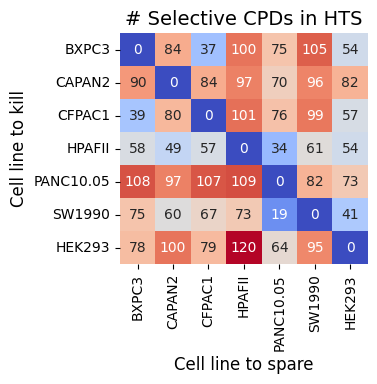

In [80]:
plt.figure(figsize=(3.2, 3))
import seaborn as sns
sns.heatmap(heatmap_df, annot=True, cmap="coolwarm", fmt="d", cbar=False)
plt.xlabel("Cell line to spare", fontsize=12)
plt.ylabel("Cell line to kill", fontsize=12)
plt.yticks(rotation=0)
plt.title("# Selective CPDs in HTS", fontsize=14)
plt.show()

## Panel e, scaffold analysis of molecules in HTS

In [7]:
from collections import Counter

In [8]:
## Different structural groups according to DSF data
print("# Different scaffold groups", len(np.unique(hts.dropna().CLNUMBER)))
print("non assigned scaffold group:", hts.CLNUMBER.isnull().sum())
count_dict = Counter(hts.CLNUMBER.dropna())
counts = []
for i in range(hts.shape[0]):
    try:
        counts.append(int(count_dict[hts.CLNUMBER.values[i]]))
    except:
        counts.append(0)
hts["counts scaffold"] = counts

# Different scaffold groups 1727
non assigned scaffold group: 2222


In [9]:
max(hts["counts scaffold"])

77

In [10]:
77/hts.shape[0]*100

0.6966434452184928

In [11]:
np.mean(list(count_dict.values()))

np.float64(5.113491603937463)

In [12]:
sum(hts[['CLNUMBER', 'counts scaffold']].drop_duplicates()['counts scaffold'] ==1)

531

In [13]:
sum(hts[['CLNUMBER', 'counts scaffold']].drop_duplicates()['counts scaffold'] >=10)

254

In [ ]:
hts['positives any'] = hts[[f'positives {cll}' for cll in standard_names[:-1]+['AsPC-1']]].max(axis=1) # Actually if we remove AsPC-1, results are better (odds ratio in Supp Fig 4)

In [36]:
actives_hts = sum(hts['positives any']==1)
teted_hts = hts.shape[0]

In [37]:
teted_hts

11053

In [38]:
ratio_hts = actives_hts / teted_hts 

In [22]:
confirmation['positives any'] = confirmation[[f'positives {cll}' for cll in standard_names[:-1]]].max(axis=1)
confirmation = confirmation[confirmation["positives any"] == 1]


In [23]:
hts = hts[hts["CLNUMBER"].isin(confirmation["CLNUMBER"])]

In [24]:
## Different structural groups according to DSF data
print("# Different scaffold groups", len(np.unique(hts.dropna().CLNUMBER)))
print("non assigned scaffold group:", hts.CLNUMBER.isnull().sum())
count_dict = Counter(hts.CLNUMBER.dropna())
counts = []
for i in range(hts.shape[0]):
    try:
        counts.append(int(count_dict[hts.CLNUMBER.values[i]]))
    except:
        counts.append(0)
hts["counts scaffold"] = counts

# Different scaffold groups 131
non assigned scaffold group: 2222


In [25]:
confirmation.columns

Index(['SMILES', 'Supplier', 'Supplier Ref', 'CLNUMBER', 'Conc', '%Inh CAPAN2',
       '%Inh SW1990', '%Inh BXPC3', '%Inh HPAFII', '%Inh CFPAC1',
       '%Inh PANC10.05', '%Inh AsPC-1', '%Inh U2OS', '%Inh HEK293',
       'positives CAPAN2', 'positives SW1990', 'positives BXPC3',
       'positives HPAFII', 'positives CFPAC1', 'positives PANC10.05',
       'positives AsPC-1', 'positives U2OS', 'positives HEK293',
       'positives any'],
      dtype='object')

In [26]:
np.mean(list(count_dict.values()))

np.float64(10.381679389312977)

In [27]:
## Different structural groups according to DSF data
print("# Different scaffold groups", len(np.unique(confirmation.dropna().CLNUMBER)))
print("non assigned scaffold group:", confirmation.CLNUMBER.isnull().sum())
count_dict = Counter(confirmation.CLNUMBER.dropna())
counts = []
for i in range(confirmation.shape[0]):
    try:
        counts.append(int(count_dict[confirmation.CLNUMBER.values[i]]))
    except:
        counts.append(0)
confirmation["counts scaffold"] = counts

# Different scaffold groups 131
non assigned scaffold group: 85


/tmp/ipykernel_9054/2005056592.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  confirmation["counts scaffold"] = counts


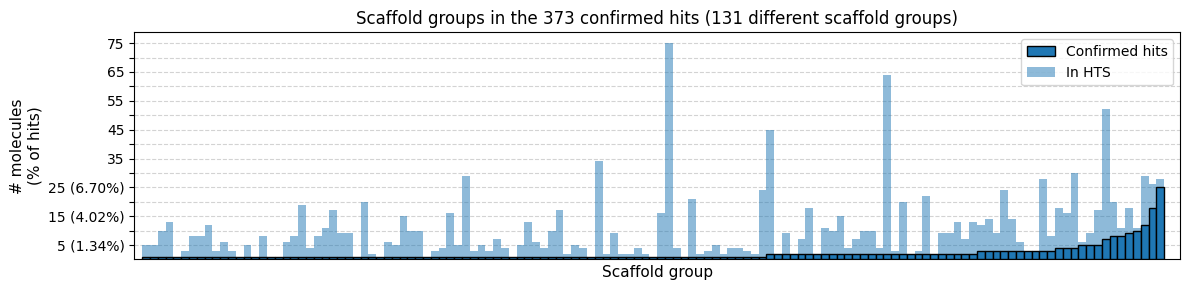

In [28]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.hist(
    confirmation.sort_values(by="counts scaffold")["CLNUMBER"].dropna(),
    bins=131,
    zorder=4,
    label="Confirmed hits",
    edgecolor="black",
)
ax.hist(
    hts["CLNUMBER"].dropna(), # it automatically matches the order from the previous plot (x axis)
    bins=131,
    zorder=2,
    alpha=0.5,
    color="tab:blue",
    label="In HTS",
)

ax.grid(axis="y", ls="--", color="lightgrey", zorder=0)

ax.set_xticks([])
labels_ = [str(x) + " (%.2f" % (x / 373 * 100) + "%)" for x in np.arange(5, 26, 10)] + [
    str(x) for x in np.arange(35, 76, 10)
]
labels = []
for element in labels_:
    labels.append(element)
    labels.append("")
ax.set_yticks(
    np.arange(5, 80, 5),
    labels=labels[:-1],
)
ax.set_title(
    "Scaffold groups in the 373 confirmed hits (131 different scaffold groups)",
    fontsize=12,
)
ax.set_xlabel("Scaffold group", fontsize=11)
ax.set_ylabel("# molecules\n(% of hits)", fontsize=11)
ax.set_xlim(-1, 132)
ax.legend()
plt.tight_layout()
plt.show()

In [29]:
int_sc = np.unique(
    confirmation.dropna(subset=["CLNUMBER"]).sort_values('counts scaffold', ascending=False)["CLNUMBER"].values
)[:5]
int_sc # top 5 scaffolds

array(['CL0017', 'CL0315', 'CL0699', 'CL0729', 'CL0732'], dtype=object)

# Supplementary fig 4

## Panel a, scaffodls with more than 5 actives and odds ratio vs HTS

In [30]:
int_sc = np.unique(
    confirmation["CLNUMBER"].values[confirmation["counts scaffold"] >= 5]
) # scaffolds with more than 5 actives

nmols_per_sc_hts = hts[hts['CLNUMBER'].isin(int_sc)][['CLNUMBER','counts scaffold']].drop_duplicates().sort_values(by='CLNUMBER', ascending=True)['counts scaffold'].values
nmols_per_sc_hts

array([11,  9, 52, 20, 18,  6, 26, 11, 28, 17, 29])

In [31]:
nmols_per_sc_conf = confirmation[confirmation['CLNUMBER'].isin(int_sc)][['CLNUMBER','counts scaffold']].drop_duplicates().sort_values(by='CLNUMBER', ascending=True)['counts scaffold'].values
nmols_per_sc_conf

array([ 8,  5,  7,  8,  9,  5, 18, 10, 25,  5, 12])

In [32]:
ratios_sc = nmols_per_sc_conf / nmols_per_sc_hts

In [33]:
ratios_sc / ratio_hts

array([12.73937473,  9.73146681,  2.35800926,  7.0066561 ,  8.75832013,
       14.59720021, 12.12690479, 15.92421841, 15.63985737,  5.15195302,
        7.24826493])

In [125]:
# Fisher's test
from scipy.stats import fisher_exact

for i in range(len(int_sc)):
    a = nmols_per_sc_conf[i]  # confirmed actives in scaffold
    total_a = nmols_per_sc_hts[i]  # total molecules in scaffold
    b = actives_hts - a  # confirmed actives not in scaffold
    total_b = teted_hts - total_a  # total molecules not in scaffold

    contingency_table = np.array([[a, total_a - a], [b, total_b - b]])

    oddsratio, p_value = fisher_exact(contingency_table, alternative='greater')
    print(f"Scaffold {int_sc[i]}: p-value = {p_value:.4e}, odds ratio = {oddsratio:.2f}", total_a, total_b)

Scaffold CL1166: p-value = 1.5299e-08, odds ratio = 44.60 11 11042
Scaffold CL1276: p-value = 6.2052e-05, odds ratio = 20.80 9 11044
Scaffold CL2028: p-value = 2.7367e-02, odds ratio = 2.59 52 11001
Scaffold CL2110: p-value = 7.3662e-06, odds ratio = 11.14 20 11033
Scaffold CL3078: p-value = 1.8593e-07, odds ratio = 16.74 18 11035
Scaffold CL4745A: p-value = 3.4150e-06, odds ratio = 83.23 6 11047
Scaffold CL6605D: p-value = 3.3387e-17, odds ratio = 38.22 26 11027
Scaffold CL6605E: p-value = 3.5870e-12, odds ratio = 167.81 11 11042
Scaffold CL6605F: p-value = 1.4486e-28, odds ratio = 143.28 28 11025
Scaffold CL6662: p-value = 2.0782e-03, odds ratio = 6.93 17 11036
Scaffold CL9233: p-value = 2.2862e-08, odds ratio = 11.87 29 11024


## Panel b, CL4745A

In [43]:
cl4745 = confirmation[confirmation["CLNUMBER"] == "CL4745A"][
    ["%Inh CAPAN2", "%Inh SW1990", "%Inh BXPC3", "%Inh HPAFII", "%Inh CFPAC1", "%Inh PANC10.05", "%Inh U2OS", "%Inh HEK293"]
]

In [48]:
cl4745

,%Inh CAPAN2,%Inh SW1990,%Inh BXPC3,%Inh HPAFII,%Inh CFPAC1,%Inh PANC10.05,%Inh U2OS,%Inh HEK293
273,42.41675,3.41655,7.70155,8.24240,15.05230,9.17245,1.81615,10.49140
274,75.10280,10.43475,9.02185,9.43740,6.08810,26.20395,-3.04490,-5.26850
275,60.99975,7.84910,5.24130,14.51175,8.82080,24.96435,-5.91020,15.79635
276,32.00665,2.13935,1.18290,10.33980,11.08325,9.19010,-7.47455,7.73945
277,54.55750,11.15555,2.40155,13.55820,9.09740,8.76625,-6.35730,6.50540


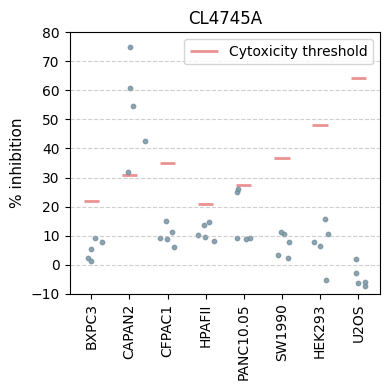

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data for plotting
cell_lines = standard_names + ['U2OS']

# Create the plot
fig, ax = plt.subplots(figsize=(4, 4))
labels = []
for i, cell_line in enumerate(cell_lines):
    labels.append(cell_line)
    # Scatter points for percent inhibition
    x = np.array([i + 1] * len(cl4745)) + np.random.normal(0, 0.15, len(cl4745))
    plt.scatter(x, cl4745['%Inh ' + cell_line], color="#738f9fff", s=10, alpha=0.8)

    # Add sensitivity thresholds
    plt.hlines(
        thresholds[cell_line],
        i + 0.8,
        i + 1.2,
        colors="tab:red",
        linestyles="-",
        lw=2,
        label="Cytoxicity threshold" if i == 0 else "",
        zorder=0,
        alpha=0.5,
    )

# Customize plot
plt.xticks(range(1, len(labels) + 1), labels, rotation=90)
plt.ylabel("% inhibition", fontsize=11)
plt.title("CL4745A", fontsize=12)
plt.ylim(-10, 80)
plt.legend(loc="upper right")
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Show plot
plt.show()